# Sites then pairs: the Labelizer chooses where, greedy Olga chooses what

*Experiment planning as a pipeline: `IMP.bff`'s native Labelizer (PRD-120) and
the greedy Olga selector on the same protein.*

An experiment planning conversation has two questions in it:

1. **Where *can* a dye go?** The Labelizer label score (LS) ranks every residue
   by how labelable it is — exposure, secondary structure, cysteine resemblance.
   Only a handful of sites are *experimentally accessible*: high enough LS, and
   actually present in the ensemble being modelled.
2. **Which pairs *should* I measure?** Greedy Olga
   (`select_probe_pairs`) takes the candidate pairs those sites define and
   orders them by the resolution each measurement buys, over an ensemble of
   candidate structures.

Neither answers the other's question: a site can be perfectly labelable yet tell
you nothing about the conformational difference under study, and the most
informative pair is worthless if the dye never attaches. This notebook composes
the two on T4 lysozyme — the same structure and ensemble as
`labelizer_score.ipynb` and `greedy_pair_selection.ipynb`:

```
3GUN-processed.pdb ──Labelizer──> labelable sites ──all pairs (|i-j| >= 10)──>
t4l_docking.rmf3 ──AV per frame──> efficiencies + RMSDs ──greedy──> ranked pairs
```

In [1]:
def example_path(relative):
    """Example data from the installed package, or from this checkout.

    ``bff.get_example_path`` reads the examples the conda module installs.
    The pip wheel deliberately does not carry them (they are 84 MB against a
    6.6 MB wheel), so it raises, and the notebook then looks for the same file
    in the repository it is running from.
    """
    import pathlib
    try:
        candidate = pathlib.Path(bff.get_example_path(str(relative)))
        if candidate.exists():
            return str(candidate)
    except Exception:
        pass
    here = pathlib.Path.cwd().resolve()
    for parent in (here, *here.parents):
        candidate = parent / "examples" / relative
        if candidate.exists():
            return str(candidate)
    raise FileNotFoundError(
        f"examples/{relative} is in neither the installed package nor a parent "
        f"of {here}: run this notebook from a checkout, or install the conda "
        f"package imp.bff, which ships the examples."
    )


In [2]:
import json, pathlib
import numpy as np
import pylab as plt

import RMF
import IMP
import IMP.atom
import IMP.core
import IMP.rmf
import IMP.bff as bff

root = example_path("structure/T4L/")
pdb, rmf_fn, fps_shipped = (root + "/3GUN-processed.pdb",
                            root + "/t4l_docking.rmf3", root + "/fret.fps.json")
ERR, R0, MIN_LS, MIN_SEP = 0.06, 52.0, 1.5, 10

## Step 1 — the labelizer's verdict: where a dye can go

The **full published model** of `labelizer_score.ipynb`, conservation included:
the ConSurf grades for T4 lysozyme live under 148L chain E on the webserver and
are pulled over its `conservationscore` endpoint — cached beside this notebook
(the same `3GUN_consurf_grades.pdb` that notebook uses; an existing file is
never fetched again, and the 148L→3GUN numbering identity check runs before the
grades are trusted). Sites pass at **LS >= 1.5** — more labelable than the
structure's average by a wide margin. The threshold is the experiment's dial:
stricter means fewer candidates for step 3, looser means the pair search
grows.

In [3]:
import pathlib

grades_file = pathlib.Path("3GUN_consurf_grades.pdb")   # 148L chain E -> chain A

if not grades_file.exists():
    import requests
    api = "https://labelizer.org/backend/"
    s = requests.Session()
    s.headers["User-Agent"] = "Mozilla/5.0"
    entry = s.get(f"{api}load_pdb/148L?db=PDB", timeout=60).json()
    chains = s.get(f"{api}conservationscore/{entry['id']}", timeout=60).json()
    text = s.get(f"{api}conservationscore/{entry['id']}/{chains['chains'][0]}",
                 timeout=120).text
    # grades are for chain E; this structure is chain A -- remap on the way in
    text = "\n".join(l[:21] + "A" + l[22:] if l.startswith("ATOM") else l
                     for l in text.splitlines())
    grades_file.write_text(text + "\n")

check = bff.labelizer_read_structure(str(grades_file))
seq_g = {r.seq_id: r.comp_id for r in check.residues if r.chain == "A"}
structure = bff.labelizer_read_structure(pdb)
seq_t4l = {r.seq_id: r.comp_id for r in structure.residues}
mismatch = [(k, seq_t4l[k], seq_g[k]) for k in sorted(set(seq_g) & set(seq_t4l))
            if seq_t4l[k] != seq_g[k]]
print(f"numbering check: {len(mismatch)} mismatches (variant sites): {mismatch}")

model = bff.labelizer_model_paper()
scores = bff.labelizer_score_structure(pdb, model, bff.LabelizerOptions(), str(grades_file))
ls = {bff.labelizer_residue_key(r.asym_id, r.seq_id): r.value
      for r in scores if r.score_type == "combined"}
resname = {r.seq_id: r.comp_id for r in structure.residues}

sites = sorted(int(k[1:]) for k, v in ls.items() if v >= MIN_LS)
print(f"{len(sites)} labelable sites (LS >= {MIN_LS}):")
print("  " + "  ".join(f"{i} {resname[i]} {ls['A'+str(i)]:.2f}" for i in sites))

numbering check: 3 mismatches (variant sites): [(26, 'THR', 'GLU'), (54, 'CYS', 'THR'), (97, 'CYS', 'ALA')]
18 labelable sites (LS >= 1.5):
  35 LYS 1.65  36 SER 1.85  40 ASN 1.69  44 SER 1.97  48 LYS 1.68  53 ASN 1.51  65 LYS 1.59  69 GLN 1.75  76 ARG 1.54  80 ARG 1.85  82 ALA 1.70  83 LYS 1.81  90 SER 1.70  93 ALA 1.64  109 THR 1.74  123 GLN 1.69  135 LYS 1.60  147 LYS 1.52


## Step 2 — the accessibility filter the labelizer cannot see

A labelling site is only real if the **ensemble models it**: a dye on a residue
that no conformer contains reports on nothing. The docking ensemble leaves the
61–84 loop unmodelled (residues 59, 81–84 missing), so two labelable sites drop
out here. This is the step that turns "labelable in the structure" into
"experimentally accessible in the ensemble".

In [4]:
m = IMP.Model()
f = RMF.open_rmf_file_read_only(rmf_fn)
hier = IMP.rmf.create_hierarchies(f, m)[0]
IMP.rmf.load_frame(f, RMF.FrameID(0))
beads = [IMP.core.XYZ(p) for p in IMP.atom.get_leaves(hier)]
frames = list(f.get_root_frames())

modelled = {IMP.atom.Residue(p).get_index()
            for p in IMP.atom.get_by_type(hier, IMP.atom.RESIDUE_TYPE)}
dropped = [i for i in sites if i not in modelled]
sites = [i for i in sites if i in modelled]
print(f"modelled residues: {len(modelled)}/162; dropped labelable sites: {dropped}")
print(f"{len(sites)} candidate sites survive: {sites}")

modelled residues: 157/162; dropped labelable sites: [82, 83]
16 candidate sites survive: [35, 36, 40, 44, 48, 53, 65, 69, 76, 80, 90, 93, 109, 123, 135, 147]


## Step 3 — the candidates: every pair the labelable sites define

All pairs with a sequence separation of at least 10 residues (neighbours FRET
trivially and are excluded), written as a fresh `fps.json` — donor `{i}D`,
acceptor `{j}A`, the same dye parameters and `RDAMean` distance type as the
shipped file. Sites serving as both donor and acceptor appear twice, as the
fps convention allows. Residues without a CB anchor at residue resolution
(warnings below) — the coarse docking beads have no side chains to attach to.

In [5]:
template = json.load(open(fps_shipped))["Positions"]["119A"]

def position(i):
    p = dict(template)
    p.update(residue_seq_number=i, residue_name=resname[i],
             strip_mask=(f"(resid {i} and not name CA+CB+C+N+O) or "
                         "resname HOH SOL WAT DU CL NA 'Cl-' 'Na+'"))
    return p

pairs = [(i, j) for n, i in enumerate(sites) for j in sites[n + 1:] if j - i >= MIN_SEP]
donors = {i for i, j in pairs}
acceptors = {j for i, j in pairs}
positions = {f"{i}D": position(i) for i in donors}
positions.update({f"{j}A": position(j) for j in acceptors})
distances = {f"{i}-{j}_C1": {
        "error_neg": 3.0, "error_pos": 3.0, "distance": 30.0,
        "position1_name": f"{i}D", "position2_name": f"{j}A",
        "Forster_radius": R0, "distance_type": "RDAMean"}
    for i, j in pairs}
fps = {"Distances": distances, "Positions": positions,
       "χ²": {"chi2_labelizer": {"distances": sorted(distances)}}}

fps_out = pathlib.Path("labelizer_sites.fps.json")
fps_out.write_text(json.dumps(fps, ensure_ascii=False, indent=1))
print(f"{len(positions)} positions, {len(distances)} candidate pairs -> {fps_out}")

27 positions, 106 candidate pairs -> labelizer_sites.fps.json


## Step 4 — what each pair would report on the ensemble

One pass over the 100 docking frames: the restraint rebuilds every dye's
accessible volume per frame and reports the mean FRET efficiency of every
candidate pair; the beads give the pairwise RMSD — the yardstick.

In [6]:
t0 = __import__("time").time()
restraint = bff.ProbeNetworkRestraint(hier, str(fps_out), score_set="chi2_labelizer")
pair_names = list(restraint.get_pair_names())

effs = np.empty((len(frames), len(pair_names)))
coords = np.empty((len(frames), len(beads), 3))
for k, frame in enumerate(frames):
    IMP.rmf.load_frame(f, frame)
    effs[k] = restraint.get_pair_efficiencies()
    coords[k] = [b.get_coordinates() for b in beads]
rmsds = bff.pairwise_rmsd(coords, True)

print(f"{len(frames)} frames x {len(pair_names)} pairs in {__import__('time').time() - t0:.1f} s")
print(f"efficiencies {effs.min():.2f}-{effs.max():.2f}, "
      f"RMSD spread {rmsds[np.triu_indices_from(rmsds, 1)].mean():.2f} A mean")

100 frames x 106 pairs in 1.8 s
efficiencies 0.12-0.99, RMSD spread 4.76 A mean


## Step 5 — greedy Olga on the labelizer's candidates

Each step adds the pair that leaves the smallest expected RMSD between the true
structure and the one the measurements would single out.

In [7]:
MAX_PAIRS = 12
selected, decay = bff.select_probe_pairs(effs, rmsds, ERR, MAX_PAIRS)
selected, decay = np.asarray(selected), np.asarray(decay)
start = bff.expected_rmsd(rmsds.ravel(), np.zeros(rmsds.size), 1, 0.99, len(frames))

print(f"{'#':>2}  {'pair':<12} {'expected RMSD':>13} {'gain':>7}")
print(f"{'-':>2}  {'(no data)':<12} {start:>11.2f} A {'':>7}")
previous = start
for rank, (idx, value) in enumerate(zip(selected, decay), start=1):
    print(f"{rank:>2}  {pair_names[idx]:<12} {value:>11.2f} A {previous - value:>6.2f} A")
    previous = value

 #  pair         expected RMSD    gain
 -  (no data)           4.71 A        
 1  80-135_C1           3.05 A   1.66 A
 2  36-147_C1           2.83 A   0.22 A
 3  35-93_C1            2.65 A   0.18 A
 4  65-123_C1           2.53 A   0.12 A
 5  53-90_C1            2.42 A   0.11 A
 6  80-147_C1           2.39 A   0.04 A
 7  48-135_C1           2.33 A   0.06 A
 8  53-147_C1           2.32 A   0.01 A
 9  44-90_C1            2.31 A   0.01 A
10  69-135_C1           2.30 A   0.01 A
11  76-147_C1           2.28 A   0.01 A
12  36-93_C1            2.27 A   0.01 A


## Step 6 — what did the labelability constraint cost?

The shipped `fret.fps.json` carries 17 hand-picked sites (33 pairs among them)
that were **not** chosen by LS. Greedy on that set, same frames, same err —
the two decay curves show what the accessibility constraint bought and what it
cost.

hand-picked sites' LS: 5:1.32, 8:1.34, 19:1.33, 22:1.13, 36:1.85, 44:1.97, 55:1.47, 60:1.44, 69:1.75, 70:0.85, 86:1.18, 119:1.48, 127:0.00, 132:0.99, 150:0.00

their median LS 1.33 vs labelizer sites' median 1.68
first pair, shipped set: 70-132_C1 (LS 0.85 / 0.99)
resolution after 5 pairs: labelizer candidates 2.42 A, shipped candidates 2.24 A (prior 4.71 A)


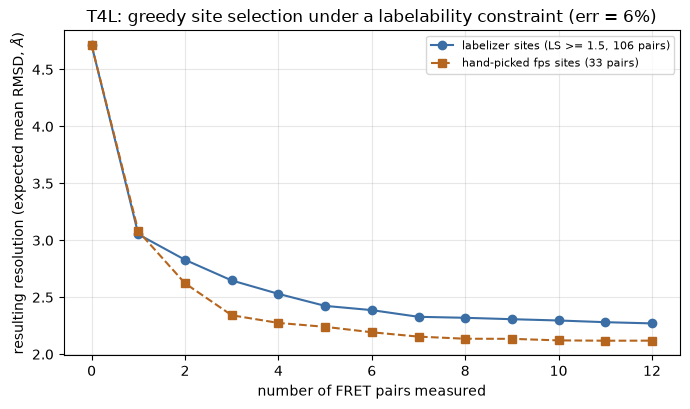

In [8]:
shipped = bff.ProbeNetworkRestraint(hier, fps_shipped, score_set="chi2_C1_33p")
shipped_names = list(shipped.get_pair_names())
effs_f = np.empty((len(frames), len(shipped_names)))
for k, frame in enumerate(frames):
    IMP.rmf.load_frame(f, frame)
    effs_f[k] = shipped.get_pair_efficiencies()

sel_f, decay_f = bff.select_probe_pairs(effs_f, rmsds, ERR, MAX_PAIRS)
decay_f = np.asarray(decay_f)

ls_of = lambda i: ls[f"A{i}"]
fps_sites = sorted({int(p[:-1]) for p in json.load(open(fps_shipped))["Positions"]})
print("hand-picked sites' LS:", ", ".join(f"{i}:{ls_of(i):.2f}" for i in fps_sites))
print(f"\ntheir median LS {np.median([ls_of(i) for i in fps_sites]):.2f} vs "
      f"labelizer sites' median {np.median([ls['A'+str(i)] for i in sites]):.2f}")
print(f"first pair, shipped set: {shipped_names[sel_f[0]]} "
      f"(LS {ls_of(int(shipped_names[sel_f[0]].split('-')[0])):.2f} / "
      f"{ls_of(int(shipped_names[sel_f[0]].split('-')[1].split('_')[0])):.2f})")
print(f"resolution after 5 pairs: labelizer candidates {decay[4]:.2f} A, "
      f"shipped candidates {decay_f[4]:.2f} A (prior {start:.2f} A)")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(np.arange(len(decay) + 1), np.concatenate([[start], decay]),
        "o-", color="#3b6ea5", label=f"labelizer sites (LS >= {MIN_LS}, {len(pair_names)} pairs)")
ax.plot(np.arange(len(decay_f) + 1), np.concatenate([[start], decay_f]),
        "s--", color="#b5651d", label=f"hand-picked fps sites ({len(shipped_names)} pairs)")
ax.set_xlabel("number of FRET pairs measured")
ax.set_ylabel("resulting resolution (expected mean RMSD, $\\AA$)")
ax.set_title(f"T4L: greedy site selection under a labelability constraint (err = {ERR:.0%})")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("labelizer_greedy_decay.png", dpi=150)
plt.show()

## Step 7 — one selector: the label score as a price, not only a gate

Steps 1–5 use the label score as a **gate** (LS ≥ 1.5) and then ignore it.
`ProbeNetworkSelection` can also weigh it inside the selection, next to Olga's
resolution. `ProbeLabellingTerm` turns the Labelizer's combined score into a
failure probability per site, `1 / (1 + LS)` (LS is a likelihood ratio), and
adds a cost per mutation, so a pair that reuses a site already chosen costs
nothing: one cysteine variant, cloned and labelled once, serves several pairs.
Both scores are losses in [0, 1], mixed by weight; weight 0 is Olga.

In [9]:
site_ids = sorted({int(x) for name in pair_names for x in name.split("_")[0].split("-")})
index = {s: k for k, s in enumerate(site_ids)}
pair_sites = np.array([[index[int(a)], index[int(b)]] for a, b in
                       (name.split("_")[0].split("-") for name in pair_names)], dtype=np.int32)
site_keys = [f"A{s}" for s in site_ids]

resolution = bff.ProbeResolutionTerm(effs, rmsds, ERR)
labelling = bff.ProbeLabellingTerm(ls, site_keys, mutation_cost=1.0)

N_PAIRS = 6
print(f"{'weight':>6} {'expected RMSD':>13} {'sites':>5} {'median LS':>9}  pairs")
priced = {}
for weight in [0.0, 0.5, 1.0]:
    net = bff.ProbeNetworkSelection(len(pair_names))
    net.set_pair_sites(pair_sites)
    net.add_term(resolution, 1.0)
    net.add_term(labelling, weight)
    picked, _ = net.select(N_PAIRS)
    used = sorted({site_ids[s] for s in pair_sites[list(picked)].ravel()})
    rmsd = np.asarray(net.get_term_losses())[:, 0] * resolution.get_initial_rmsd()
    priced[weight] = (rmsd, used)
    print(f"{weight:>6.1f} {rmsd[-1]:>11.2f} A {len(used):>5} "
          f"{np.median([ls[f'A{s}'] for s in used]):>9.2f}  "
          f"{', '.join(pair_names[i].split('_')[0] for i in picked)}")

weight expected RMSD sites median LS  pairs
   0.0        2.39 A    10      1.64  80-135, 36-147, 35-93, 65-123, 53-90, 80-147
   0.5        2.55 A     5      1.68  80-135, 80-147, 36-147, 48-135, 48-147, 48-80
   1.0        2.72 A     4      1.64  80-135, 48-135, 48-80, 80-147, 48-147, 135-147


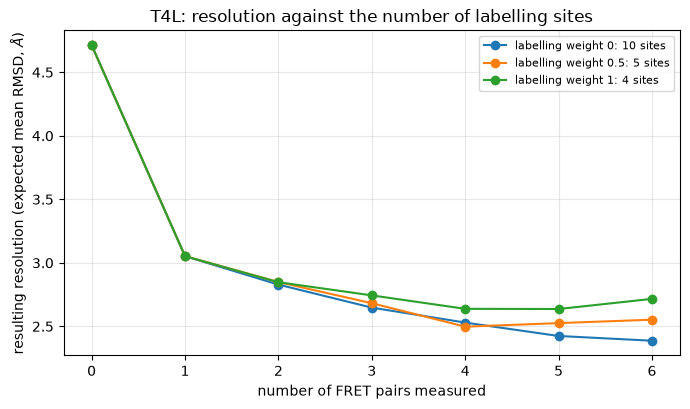

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for weight, (rmsd, used) in priced.items():
    ax.plot(np.arange(len(rmsd) + 1), np.concatenate([[start], rmsd]), "o-",
            label=f"labelling weight {weight:g}: {len(used)} sites")
ax.set_xlabel("number of FRET pairs measured")
ax.set_ylabel("resulting resolution (expected mean RMSD, $\\AA$)")
ax.set_title("T4L: resolution against the number of labelling sites")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("labelizer_greedy_priced.png", dpi=150)
plt.show()

## Reading the pipeline

- **The two stages compose cleanly**: the labelizer turns "any residue" into a
  shortlist of labelable, ensemble-accessible sites (18 → 16 after the
  unmodelled-loop filter); greedy turns that shortlist into an ordered
  experiment. Neither step could do the other's job — LS is silent about the
  ensemble, the selector is silent about chemistry.
- **Conservation is in the model now**, so the shortlist itself changed against
  earlier no-conservation runs: sites 53, 65, 76, 93 and 147 enter, 21, 52 and
  55 leave — and the candidate pool grows from 92 to 106 pairs. The grades are
  T4 lysozyme's own ConSurf run (148L chain E), pulled from the webserver API
  and cached; the same file `labelizer_score.ipynb` uses.
- **The labelability constraint is nearly free here.** After five pairs the
  labelizer-constrained candidates sit at 2.42 A against 2.24 A for the
  hand-picked set — and its first pair (`80-135`, 1.66 A) edges out the shipped
  set's celebrated `70-132` (1.63 A). What the constraint buys is chemistry:
  the hand-picked sites' median LS is 1.33 against 1.68, and two of them (127,
  150) are vetoed outright by the model — LS 0, a dye the model does not expect
  to behave.
- **The dial is `MIN_LS`.** The shipped set's best first pair lives on sites 70
  and 132, whose LS (0.85, 0.99) falls far below the threshold — lowering
  `MIN_LS` re-enters them and the two curves converge. The dial trades candidate
  coverage for confidence that every dye actually behaves; this plot is how
  that trade is priced.
- **Priced, the label score changes the experiment, not only the shortlist**
  (step 7). Olga's six pairs need ten labelling sites and reach 2.39 Å. At
  labelling weight 0.5 the selector reuses sites, and five sites carry six
  pairs at 2.55 Å. At weight 1 four sites carry all six (every pair among 48,
  80, 135 and 147) at 2.72 Å. Half the cysteine variants for 0.16 Å is the
  kind of trade this makes explicit. The kinetics side of the same selector is
  in `greedy_pair_selection.ipynb`.